# 03 — Analyse exploratoire (EDA)

On explore le dataset enrichi (`data/processed/btc_features.csv`) pour comprendre le comportement du BTC et repérer les features les plus liées à la **volatilité future**.

> Partie 3 du projet, réalisée par Amandine.

## Partie 1 — Chargement & aperçu

On charge le dataset enrichi et on vérifie les colonnes disponibles.

In [7]:
# Importation des outils
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de la taille des graphiques
plt.rcParams['figure.figsize'] = (10, 5)

# Indication du chemin de fichier pour Pandas
df = pd.read_csv("../data/processed/btc_features.csv")

# On affiche le tableau
df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,...,trade_intensity,buy_pressure,hour,day_of_week,rv_6h,rv_72h,rv_168h,parkinson,atr_14,vol_ma_ratio
0,2025-12-08 00:00:00,90395.32,90627.11,89860.00,90346.70,491.62319,2025-12-08 00:59:59.999999,4.439289e+07,228906,256.18633,...,465.612698,0.521103,0,0,0.007533,0.004829,0.005132,0.005105,0.010058,0.889554
1,2025-12-08 01:00:00,90346.70,91700.00,90301.86,90910.70,968.78312,2025-12-08 01:59:59.999999,8.825350e+07,335046,489.80674,...,345.842112,0.505590,1,0,0.008216,0.004889,0.005151,0.009227,0.010988,1.648937
2,2025-12-08 02:00:00,90910.70,91436.94,90811.25,91364.18,597.40749,2025-12-08 02:59:59.999999,5.443266e+07,210484,357.39473,...,352.329028,0.598243,2,0,0.008571,0.004922,0.005147,0.004124,0.011052,0.987309
3,2025-12-08 03:00:00,91364.18,91420.00,90988.91,91068.29,395.79035,2025-12-08 03:59:59.999999,3.608552e+07,155098,183.42352,...,391.869079,0.463436,3,0,0.006147,0.004913,0.005141,0.002839,0.010746,0.643464
4,2025-12-08 04:00:00,91068.30,91470.58,91023.06,91291.33,255.62144,2025-12-08 04:59:59.999999,2.332086e+07,142871,128.84761,...,558.916341,0.504056,4,0,0.004495,0.004921,0.005118,0.002945,0.009985,0.416284


In [ ]:
print(df.columns.tolist())

## Partie 2 — Évolution dans le temps

Prix, volume et volatilité passée au fil des heures.

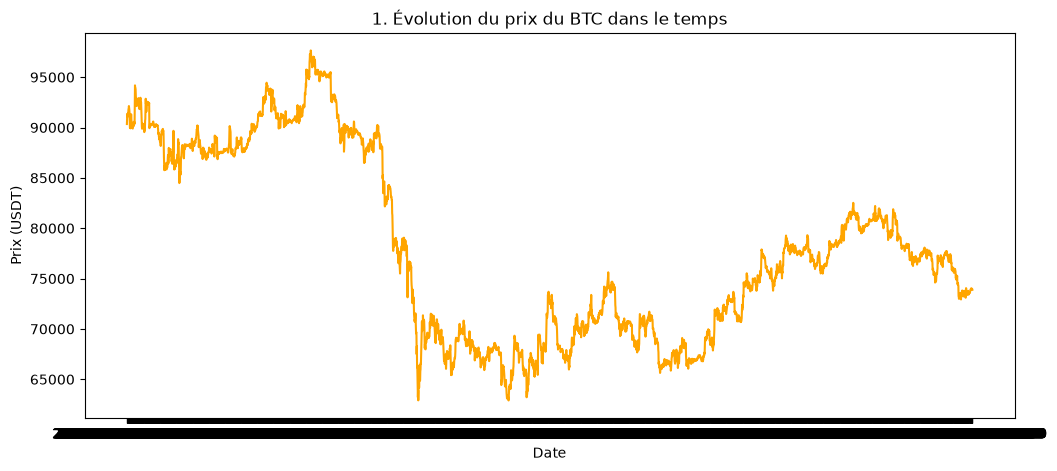

In [9]:
# Préparation de la toile
plt.figure(figsize=(12, 5))

# Création de la courbe avec la date en bas (X) et le prix sur le côté (Y)
plt.plot(df['open_time'], df['close'], color='orange')

# Ajout des titres
plt.title('1. Évolution du prix du BTC dans le temps')
plt.xlabel('Date')
plt.ylabel('Prix (USDT)')

# Affichage du graphique
plt.show()

L'évolution du prix de clôture du Bitcoin sur cette période montre les tendances générales du marché, alternant entre des phases de hausse et des corrections.



---



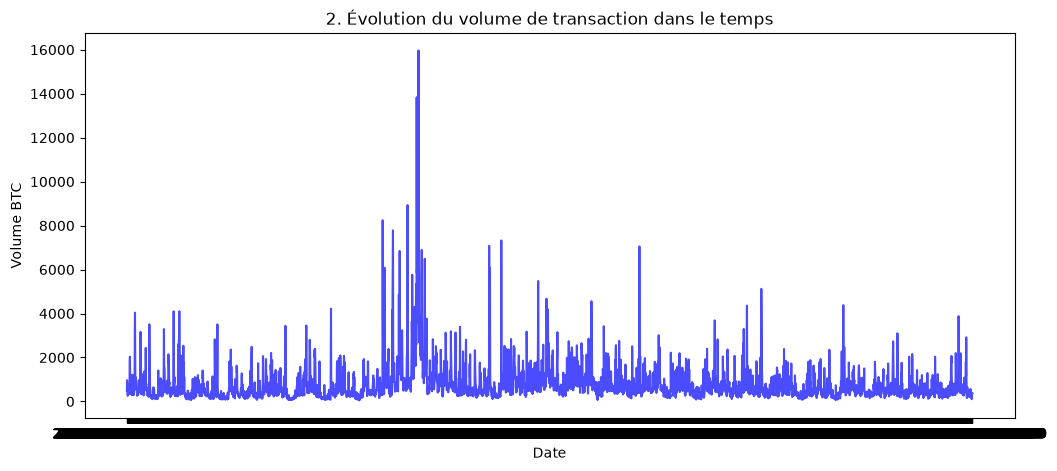

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(df['open_time'], df['volume'], color='blue', alpha=0.7)

plt.title('2. Évolution du volume de transaction dans le temps')
plt.xlabel('Date')
plt.ylabel('Volume BTC')

plt.show()

Le volume de transactions n'est pas constant. On remarque des pics d'activité très nets à certains moments, ce qui indique que les acheteurs et vendeurs sont soudainement très actifs sur le marché.



---



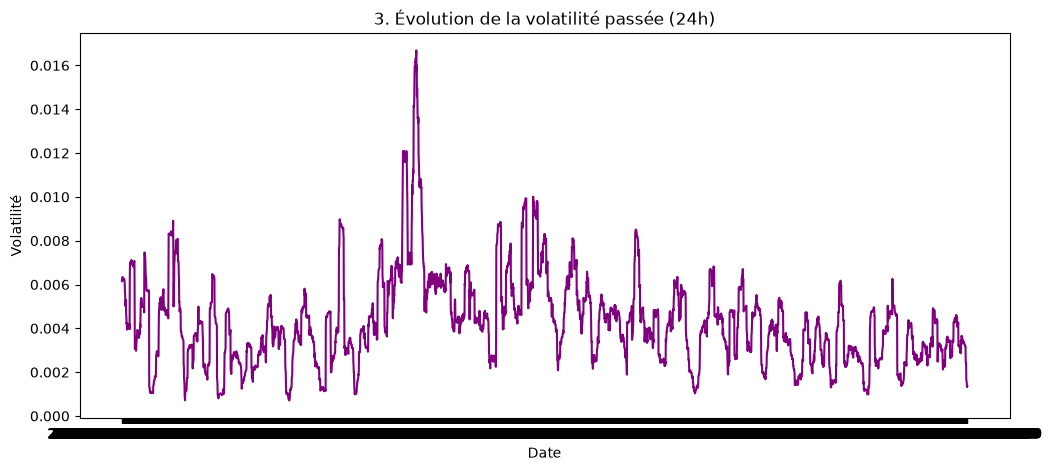

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(df['open_time'], df['volatility_24h_past'], color='purple')

plt.title('3. Évolution de la volatilité passée (24h)')
plt.xlabel('Date')
plt.ylabel('Volatilité')

plt.show()

La volatilité n'est pas constante. On distingue clairement des périodes très calmes (plateaux bas) et des périodes très agitées avec de forts pics de volatilité.



---



## Partie 3 — Distributions

Répartition des rendements horaires et de la target (volatilité future).

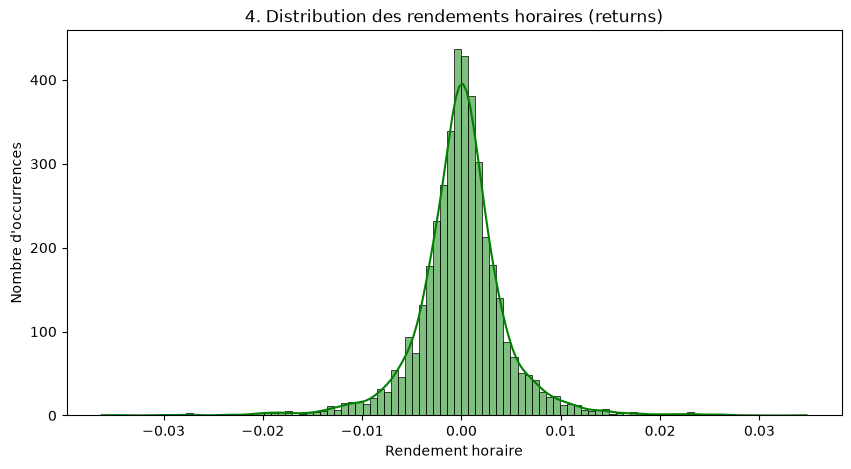

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(df['return_1h'], bins=100, kde=True, color='green')

plt.title('4. Distribution des rendements horaires (returns)')
plt.xlabel('Rendement horaire')
plt.ylabel('Nombre d\'occurrences')

plt.show()

L'histogramme montre que la grande majorité des variations horaires sont très proches de zéro. Cependant, les bouts de part et d'autre indiquent qu'il y a de temps en temps des variations extrêmes.



---



In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['volatility_24h_future'], bins=100, kde=True, color='red')

plt.title('5. Distribution de la volatilité future (Notre Target)')
plt.xlabel('Volatilité future (24h)')
plt.ylabel('Nombre d\'occurrences')

plt.show()

La distribution de notre cible est asymétrique. Les périodes de faible volatilité sont beaucoup plus fréquentes que les périodes de très forte volatilité.



---



## Partie 4 — Corrélations & relations

Quelles variables sont le plus liées à la volatilité future.

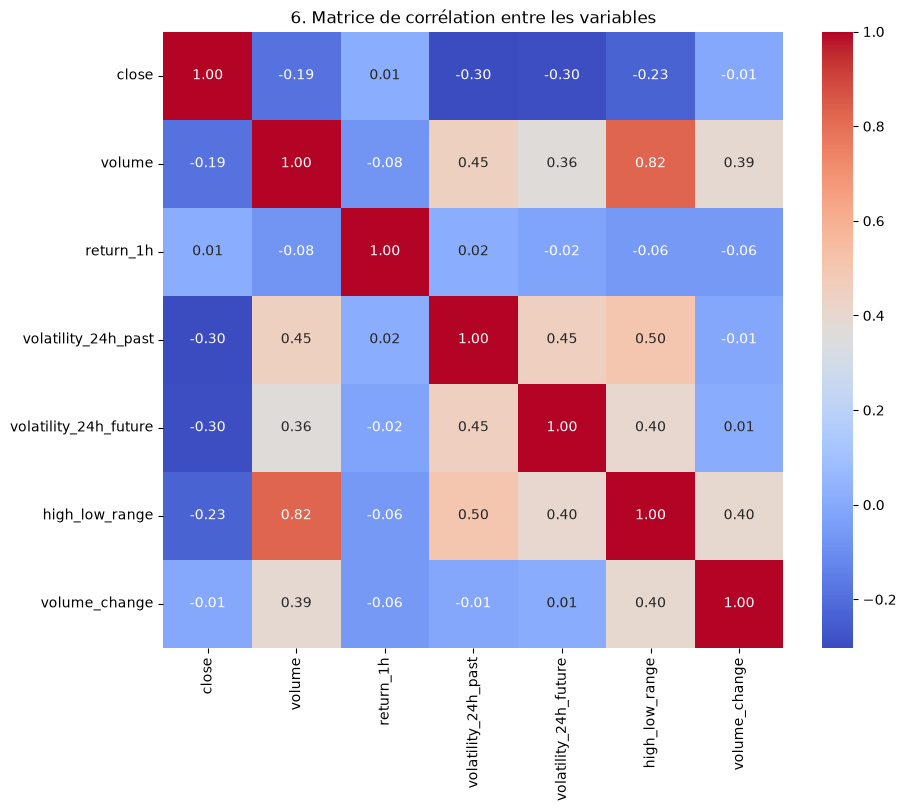

In [13]:
plt.figure(figsize=(10, 8))

colonnes = ['close', 'volume', 'return_1h', 'volatility_24h_past', 'volatility_24h_future', 'high_low_range', 'volume_change']

sns.heatmap(df[colonnes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('6. Matrice de corrélation entre les variables')

plt.show()

La carte de chaleur (heatmap) révèle que la volatilité passée et l'amplitude des prix (high_low_range) sont fortement corrélées à la volatilité future. Ce sont de bons indicateurs pour notre futur modèle prédictif.



---



In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='volume_change', y='volatility_24h_future', alpha=0.5, color='teal')

plt.title('7. Impact de la variation du volume sur la volatilité future')
plt.xlabel('Variation horaire du volume (volume_change)')
plt.ylabel('Volatilité future (24h)')

plt.show()

Le nuage de points est très centré. Une simple variation brutale du volume sur une heure ne garantit pas toujours une forte volatilité pour les 24h suivantes.



---



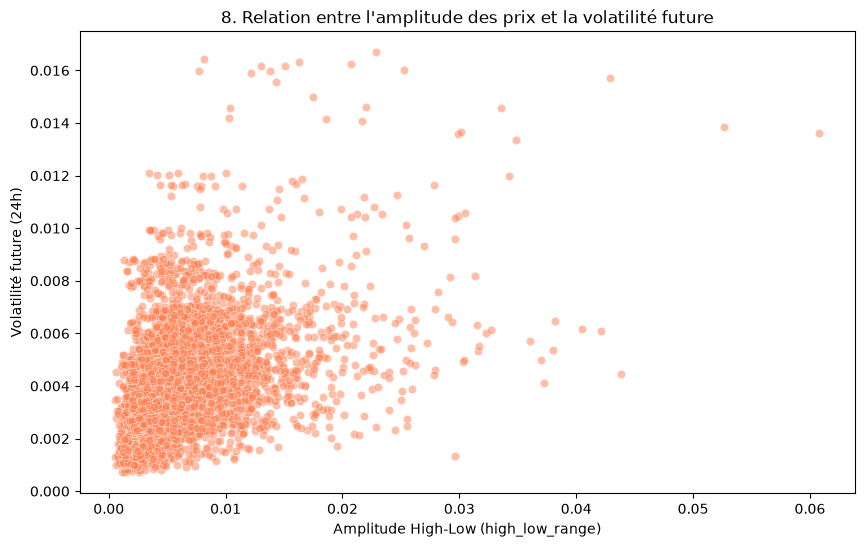

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='high_low_range', y='volatility_24h_future', alpha=0.5, color='coral')

plt.title('8. Relation entre l\'amplitude des prix et la volatilité future')
plt.xlabel('Amplitude High-Low (high_low_range)')
plt.ylabel('Volatilité future (24h)')

plt.show()

On observe une tendance claire : les périodes avec une forte amplitude high-low sont souvent associées à une volatilité future plus élevée. C'est une feature majeure pour notre projet.



---



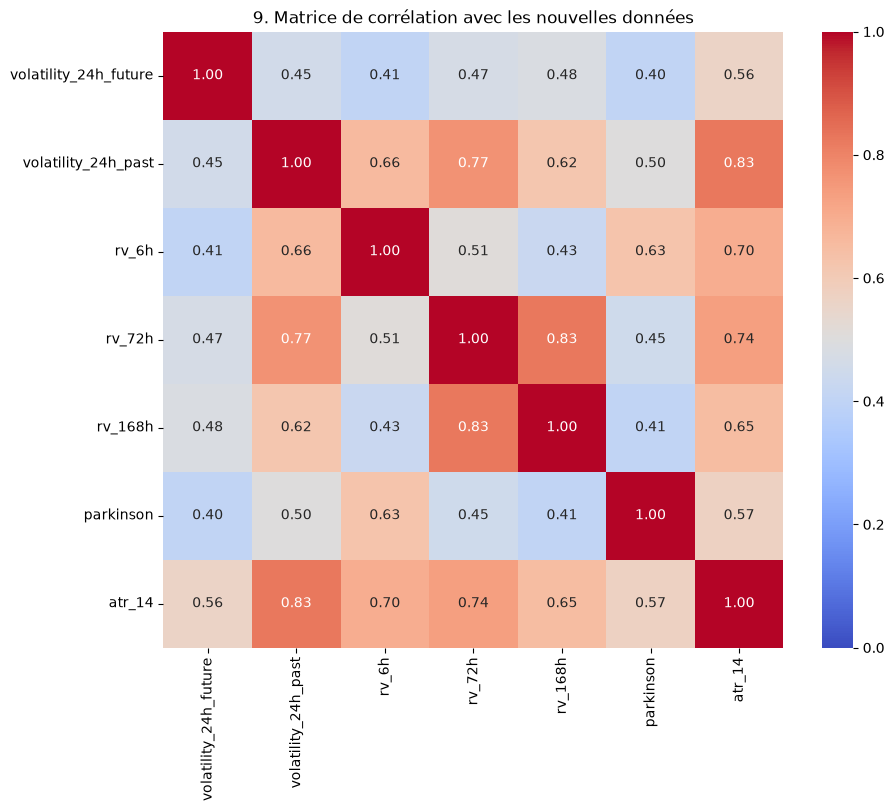

In [15]:
plt.figure(figsize=(10, 8))

new_columns = [
    'volatility_24h_future',
    'volatility_24h_past',
    'rv_6h',
    'rv_72h',
    'rv_168h',
    'parkinson',
    'atr_14'
]

sns.heatmap(df[new_columns].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=0, vmax=1)
plt.title('9. Matrice de corrélation avec les nouvelles données')
plt.show()

La volatilité du Bitcoin dépend de plusieurs horizons de temps (court, moyen et long terme). On observe sur cette nouvelle matrice que les indicateurs rv_168h (7 jours) et rv_72h (3 jours) apportent une information nouvelle et très corrélée à notre target. L'estimateur de parkinson est également un bon signal. L'ajout de ces dimensions temporelles est la clé pour stabiliser notre modèle prédictif.